In [5]:
from glob import glob
import pickle as pk
import numpy as np
import dfibers.fixed_points as fx
from ising_finder import get_loss_factory
import torch as tr
import re

def kron_prod(op_list):
    """Calculates the Kronecker product of a list of operators."""
    result = op_list[0]
    for op in op_list[1:]:
        result = tr.kron(result, op)
    return result


pauli = [
    tr.tensor([[1.0, 0.0], [0.0, 1.0]], dtype=tr.complex128),
    tr.tensor([[0.0, 1.0], [1.0, 0.0]], dtype=tr.complex128),
    tr.tensor([[0.0, -1j], [1j, 0.0]], dtype=tr.complex128),
    tr.tensor([[1.0, 0.0], [0.0, -1.0]], dtype=tr.complex128),
]

# number of qubits
n_qb = 6
# initial params
h=1.5; J = 1
initial_params = tr.tensor([[0, 0, h, J, 0, 0, 0, 0, h, -J, 0, 0]])

def get_Hamiltonian(c):
    """Creates the general ising Hamiltonian with boundary terms"""
    # c = [K,12], K is batch size
    K = c.shape[0]
    I_list = [pauli[0]] * n_qb
    H = tr.zeros((K, 2**n_qb, 2**n_qb), dtype=tr.complex128)

    # Interaction terms and Single Site terms
    for i in range(n_qb - 1):
        for p in range(1, 4):
            interaction_list = I_list[:]
            interaction_list[i] = pauli[p]
            interaction_list[i + 1] = pauli[p]

            single_term = I_list[:]
            single_term[i] = pauli[p]

            H += c[:, p - 1].view(K, 1, 1) * kron_prod(interaction_list) + c[
                :, 3 + p - 1
            ].view(K, 1, 1) * kron_prod(single_term)

    # Boundary Terms
    for p in range(1, 4):
        site_one = I_list[:]
        site_one[0] = pauli[p]

        site_N = I_list[:]
        site_N[n_qb - 1] = pauli[p]

        H += c[None, :, 6 + p - 1].view(K, 1, 1) * kron_prod(site_one) + c[
            None, :, 9 + p - 1
        ].view(K, 1, 1) * kron_prod(site_N)

    return H


def get_spectrum(c):
    # c is (K, 12) tensor, K is batch size
    H = get_Hamiltonian(c)
    try:
        spectrum = tr.linalg.eigvalsh(H)  # (K, 2**n_qb)
    except tr._C._LinAlgError:
        print("Erorr computing eigenvalues")
        with open("ErrorHamiltonian.txt", "w") as f:
            f.write(str(H))
            f.write("__________________________________\n")
        return np.inf
    return spectrum

init_spectrum = get_spectrum(initial_params)

def compute_diff_spectrum(R_i):
    lambda_i = get_spectrum(R_i)
    diff = tr.sum((lambda_i - init_spectrum) ** 2, dim=1)

    return diff


In [2]:
name = "0.1.x1.pkl"
split_name = re.split(".pkl", name)[0]
split_name = re.split("1.", split_name)[1]
split_name

'x1'

In [6]:
initial_starting_points = {}

directions =["xx", "yy", "zz", "x", "y", "z", "x1", "y1", "z1", "xn", "yn", "zn"]
magnitudes = [-1, -.1, -0.01, .01, .1, 1]

image_vectors:dict[str,np.ndarray] = {dir:np.empty((12,0)) for dir in directions}

image_vectors:dict[str,np.ndarray] = {dir:np.empty((12,0)) for dir in directions}
                            
file_list = []
file_list.extend(glob("results/perturbed_values/*.pkl"))


for file in file_list:
    split_name = re.split(".pkl", file)[0]   
    split_name = re.split("1.", split_name)[1]


    with open(file, "rb") as f:
        (c_targ, V, A, R) = pk.load(f)

        # Add initial starting point
        isp = c_targ
        get_loss = get_loss_factory(c_targ)

        # Filter duplicate points and high-loss points
        duplicates = lambda U, v: (np.fabs(U - v) < 0.1).all(axis=0)
        R_init:np.ndarray = R.copy()
        R = fx.get_unique_points(R, duplicates)

        loss = get_loss(tr.tensor(R.T))
        keep = loss.numpy() < 1e-8

        # Trim arrays
        R = R[:, keep]

        # Store resulting trimmed results
        arr = np.concatenate(
            (image_vectors[split_name], R.reshape(12,R.shape[1])), axis=1
        )
        
    image_vectors[split_name] = arr
    initial_starting_points[split_name] = np.array(isp)



/tmp/ipykernel_2852/1500082629.py:43: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  initial_starting_points[split_name] = np.array(isp)


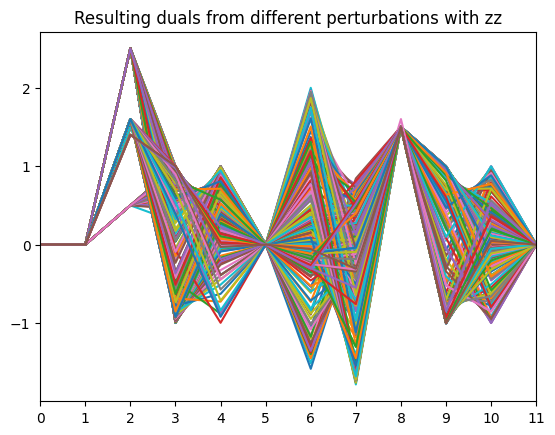

In [9]:
import matplotlib.pyplot as plt

direction = "zz"
plt.plot(image_vectors[direction])
plt.xlim(0,11)
plt.xticks(range(12))
plt.title(f"Resulting duals from different perturbations with {direction}")

plt.show()